# Стартовые импорты

In [ ]:
!pip install playwright nest-asyncio beautifulsoup4 markdownify
!playwright install chromium
!playwright install-deps chromium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 MB 15.1 MB/s eta 0:00:00
175.4 MiB [] 0% 361.4s175.4 MiB [] 0% 59.6s175.4 MiB [] 0% 34.9s175.4 MiB [] 0% 26.4s175.4 MiB [] 0% 24.1s175.4 MiB [] 0% 19.1s175.4 MiB [] 0% 11.5s175.4 MiB [] 1% 7.8s175.4 MiB [] 2% 8.0s175.4 MiB [] 2% 9.1s175.4 MiB [] 2% 9.8s175.4 MiB [] 2% 10.5s175.4 MiB [] 2% 11.2s175.4 MiB [] 2% 11.8s175.4 MiB [] 2% 11.9s175.4 MiB [] 3% 9.7s175.4 MiB [] 3% 8.4s175.4 MiB [] 4% 7.4s175.4 MiB [] 5% 6.8s175.4 MiB [] 5% 6.2s175.4 MiB [] 6% 5.8s175.4 MiB [] 7% 5.5s175.4 MiB [] 7% 5.9s175.4 MiB [] 7% 5.8s175.4 MiB [] 7% 6.0s175.4 MiB [] 8% 6.0s175.4 MiB [] 8% 6.2s175.4 MiB [] 8% 6.3s175.4 MiB [] 8% 6.6s175.4 MiB [] 8% 6.3s175.4 MiB [] 9% 6.2s175.4 MiB [] 9% 5.9s175.4 MiB [] 10% 5.6s175.4 MiB [] 11% 5.4s175.4 MiB [] 11% 5.2s175.4 MiB [] 12% 5.0s175.4 MiB [] 13% 4.8s175.4 MiB [] 13% 4.7s175.4 MiB [] 14% 4.7s175.4 MiB [] 14% 4.6s175.4 MiB [] 15% 4.6s175.4 MiB [] 15% 4.5s175.4 MiB [] 16% 4.5s175.4 MiB [] 16% 4.4s175.4 MiB [] 17% 

In [ ]:
!pip install rank_bm25

In [ ]:
!pip install playwright

In [ ]:
!python -m playwright install
!python -m playwright install-deps

104.3 MiB [] 0% 0.0s104.3 MiB [] 0% 15.7s104.3 MiB [] 0% 11.3s104.3 MiB [] 0% 9.9s104.3 MiB [] 1% 5.3s104.3 MiB [] 1% 4.6s104.3 MiB [] 2% 4.1s104.3 MiB [] 3% 3.5s104.3 MiB [] 3% 3.3s104.3 MiB [] 4% 3.3s104.3 MiB [] 4% 3.4s104.3 MiB [] 4% 3.6s104.3 MiB [] 4% 3.8s104.3 MiB [] 5% 4.0s104.3 MiB [] 5% 4.1s104.3 MiB [] 5% 4.2s104.3 MiB [] 5% 4.4s104.3 MiB [] 5% 4.5s104.3 MiB [] 6% 4.6s104.3 MiB [] 6% 4.7s104.3 MiB [] 6% 4.9s104.3 MiB [] 6% 5.2s104.3 MiB [] 6% 5.3s104.3 MiB [] 7% 5.2s104.3 MiB [] 7% 5.1s104.3 MiB [] 8% 4.9s104.3 MiB [] 8% 5.0s104.3 MiB [] 8% 5.1s104.3 MiB [] 9% 5.2s104.3 MiB [] 9% 5.3s104.3 MiB [] 9% 5.2s104.3 MiB [] 10% 5.2s104.3 MiB [] 11% 5.2s104.3 MiB [] 11% 5.3s104.3 MiB [] 12% 5.3s104.3 MiB [] 12% 5.6s104.3 MiB [] 12% 5.8s104.3 MiB [] 12% 5.9s104.3 MiB [] 13% 6.0s104.3 MiB [] 13% 6.1s104.3 MiB [] 13% 6.2s104.3 MiB [] 13% 6.3s104.3 MiB [] 13% 6.5s104.3 MiB [] 13% 6.6s104.3 MiB [] 14% 6.3s104.3 MiB [] 14% 6.1s104.3 MiB [] 15% 6.0s104.3 MiB [] 15% 5.9s104.3 MiB [] 16% 5.8s

In [ ]:
import os
import asyncio
import nest_asyncio
import re
from bs4 import BeautifulSoup
from markdownify import markdownify as md
from playwright.async_api import async_playwright
import urllib.parse

# Парсинг

**Маршрут решения**\
С парсингом сайтов до этого не работал, поэтому маршрут получился длинный
1. Попробовал обойтись Requests + BeautifulSoup. Как итог собрал весь мусор с сайта (боковые панели, календари, кнопки и т. д.)
2. Пришёл к необходимости рендерить страницу перед парсингом, начал настраивать Selenium, но в колабе у меня не получилось его запустить
3. Вместо Selenium нагуглил Playwright, он запустился, но скачивал 0 статей. Это было связано с тем, что он останавливался в корневых каталогах и не доходил до самих статей
4. Более внимательно проанализировал сайт, собрал все мусорные классы и выделил контейнер с текстом .article-detail-content
5. В итоговом варианте мы проходим алгоритмом BFS, собираем все страницы, на этих страницах выделяем блок текста текст, удаляем из него все лишние классы и получаем почти идеально чистые файлы

**Логика парсинга**:

1. **Инициализация:** Определяются базовый URL `(BASE_URL)` и директория для сохранения `(SAVE_DIR)`. Создается пустая папка для статей.
2. **Запуск браузера:** `playwright` запускает `Chromium`
3. **Очередь обхода:** Инициализируются список `to_visit` (очередь URL для посещения, начинается с `BASE_URL`) и множество `visited` (чтобы избежать повторного посещения страниц).
4. **Цикл обхода:** Продолжается, пока есть ссылки в `to_visit` и не достигнут лимит (300 страниц достаточно в текущей версии сайта достаточно)
4. **Переход по URL:** Паук переходит на текущий URL. Используется дополнительный таймаут ля уверенности, что весь контент загрузился.
5. **Получение HTML:** Извлекается HTML-содержимое страницы
6. **Поиск ссылок:** BeautifulSoup ищет все ссылки на странице. Фильтруются только те, которые ведут на статьи `(/articles/)`. Ссылки добавляются в `to_visit`, если они еще не были посещены.
7. **Проверка на статью:** Ищется конкретный HTML-элемент (по классу `article-detail-content`), который обозначает, что страница является полноценной статьей, а не просто хабом или оглавлением. Если это хаб, статья не сохраняется, но ссылки с него обрабатываются.
8. **Очистка контента:** Из найденного блока статьи удаляются "мусорные" элементы (футеры, сайдбары, скрипты, кнопки и т.д.), которые не являются частью основного текста статьи.
9. **Извлечение заголовка:** Извлекается текст `<h1>` для использования в качестве имени файла.
10. **Конвертация в Markdown:** Очищенный HTML-контент конвертируется в Markdown с помощью markdownify.
11. **Сохранение:** Если полученный Markdown достаточно большой (более 150 символов), он сохраняется в файл с названием, основанным на заголовке статьи, в папке `SAVE_DIR`.
12. **Обработка ошибок:** Вся логика обхода страницы заключена в try-except блок, чтобы ошибки на одной странице не останавливали весь процесс.
13. **Завершение:** После обхода всех страниц браузер закрывается, и выводится итоговая статистика.


In [ ]:
parse = False # по умолчанию True

In [ ]:
import shutil
import os
from google.colab import drive

In [ ]:
if parse:
  nest_asyncio.apply()

  BASE_URL = "https://academy.lamoda.ru"
  SAVE_DIR = "lamoda_articles_md"
  os.makedirs(SAVE_DIR, exist_ok=True)

  async def spider_parser():
      print("Запускаем глубокий обход (Spider/Crawler)...")

      async with async_playwright() as p:
          browser = await p.chromium.launch(headless=True)
          context = await browser.new_context()
          page = await context.new_page()

          to_visit = [BASE_URL]
          visited = set()
          saved_count = 0

          while to_visit and len(visited) < 300: # чтобы не улететь в бесконечность
              current_url = to_visit.pop(0)
              if current_url in visited:
                  continue

              visited.add(current_url)
              print(f"\nОбход: {current_url}")

              try:
                  await page.goto(current_url, wait_until="domcontentloaded", timeout=15000)
                  await page.wait_for_timeout(2000) # чтобы дождаться загрузки страницы

                  html = await page.content()
                  soup = BeautifulSoup(html, 'html.parser')

                  # собираем все ссылки на странице и добавляем в очередь
                  for a in soup.find_all('a', href=True):
                      href = a['href']
                      if '/articles/' in href:
                          full_url = urllib.parse.urljoin(BASE_URL, href).split('#')[0].split('?')[0]
                          if full_url not in visited and full_url not in to_visit:
                              to_visit.append(full_url)

                  # проверяем, что это вообще статья
                  article_content = soup.find(class_=re.compile(r'article-detail-content', re.I))

                  if not article_content:
                      print("  [SKIP] Это хаб-оглавление. Ссылки из него добавлены в очередь, идем дальше.")
                      continue

                  # удаляем мусор внутри статьи
                  trash_classes = ['article-feedback', 'article-detail-share', 'article-detail-tags', 'sidebar', 'top-menu', 'header-outer', 'cookie']
                  for trash in trash_classes:
                      for el in article_content.find_all(class_=re.compile(trash, re.I)):
                          el.decompose()

                  for el in article_content(["script", "style", "svg", "button", "iframe"]):
                      el.decompose()

                  # название файла
                  h1 = soup.find('h1')
                  title = h1.text.strip() if h1 else current_url.split('/')[-2]
                  safe_title = "".join(c if c.isalnum() or c.isspace() else "_" for c in title)[:60].strip()

                  # конвертим в markdown
                  markdown_text = md(str(article_content), heading_style="ATX", strip=['img', 'a'])

                  cleaned_lines = [line.strip() for line in markdown_text.split('\n') if line.strip()]
                  final_text = "\n".join(cleaned_lines)

                  if len(final_text) > 150:
                      file_path = os.path.join(SAVE_DIR, f"{safe_title}.md")
                      with open(file_path, 'w', encoding='utf-8') as f:
                          f.write(final_text)
                      print(f"  [OK] Сохранена статья: {safe_title}.md")
                      saved_count += 1
                  else:
                      print("  [SKIP] Текста слишком мало.")

              except Exception as e:
                  print(f"  [ERROR] Ошибка при обходе: {e}")

          await browser.close()
          print(f"\nИтог: Успешно скачано {saved_count} статей. Всего проверено страниц: {len(visited)}")

  asyncio.run(spider_parser())

In [ ]:
if not parse:
  drive.mount('/content/drive')

  DRIVE_ARCHIVE = "/content/drive/MyDrive/lamoda_articles.zip"
  LOCAL_ARCHIVE = "lamoda_articles_imported.zip"
  TARGET_DIR = "lamoda_articles_md"

  if os.path.exists(DRIVE_ARCHIVE):
      print("Копирование архива с диска...")
      shutil.copy(DRIVE_ARCHIVE, LOCAL_ARCHIVE)

      print("Распаковка файлов...")
      shutil.unpack_archive(LOCAL_ARCHIVE, TARGET_DIR)

      files_count = len([name for name in os.listdir(TARGET_DIR) if name.endswith('.md')])
      print(f"[OK] База успешно восстановлена! Загружено статей: {files_count}")
  else:
      print("[FAIL] Ошибка: Архив lamoda_articles.zip не найден на Google Диске.")

Mounted at /content/drive
Копирование архива с диска...
Распаковка файлов...
[OK] База успешно восстановлена! Загружено статей: 213


## Сохранение на Google Drive

Обход траулера в текущей версии занимает около 15 минут, реализовал сохранение в Google Диск, чтобы при отладке каждый раз не ждать

In [ ]:
save = False # по умолчанию False

In [ ]:
if save:
  drive.mount('/content/drive')

  SOURCE_DIR = "lamoda_articles_md"
  ARCHIVE_NAME = "lamoda_articles"
  DRIVE_DESTINATION = "/content/drive/MyDrive/lamoda_articles.zip"

  print("Архивация файлов...")
  shutil.make_archive(ARCHIVE_NAME, 'zip', SOURCE_DIR)

  print("Копирование на Google Диск...")
  shutil.copy(f"{ARCHIVE_NAME}.zip", DRIVE_DESTINATION)

  print("Успешно!")

# Ретривер

**Архитектура ретривера**\
После получения очищенного от HTML-тегов, элементов навигации и скриптов Markdown-текста был реализован пайплайн ретривера:
1. Модель небольшая, текст целиком лучше не помещать, поэтому использовал алгоритм скользящего окна. Документы нарезаются на фрагменты по 800 символов с перекрытием в 150 символов
2. В качестве Dence-модели  для векторного поиска выбрал `cointegrated/rubert-tiny2`, она очень маленькая и хорошо работает с русским языком
3. Добавил алгоритм `BM25` для лучшего поиска по аббревиатурам и числам, у нас их много (FBS, FBS, УПК, ЛК и т. д.)
4. Для корректного смешивания sparse и dense применяется min-max нормализация. Обе шкалы оценок независимо приводятся к единому отрезку [0.0, 1.0].

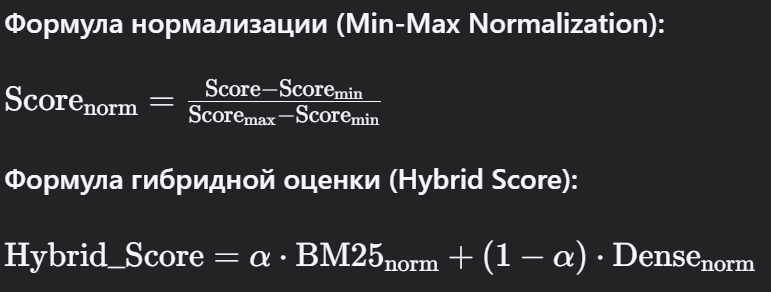

5. Значения параметра настраивают поиск, где 1.0 - поиск только по точным ключевым словам, а 0.0 - только по смыслу. В проекте использован alpha=0.3, на практике это оптимальное значение

In [ ]:
import glob
import numpy as np
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
from sklearn.metrics.pairwise import cosine_similarity
import re

In [ ]:
SAVE_DIR = "lamoda_articles_md"
CHUNK_SIZE = 800  # максимальный размер чанка в символах
CHUNK_OVERLAP = 150 # перекрытие чанков для сохранения контекста на стыках

## Чтение и подготовка данных

In [ ]:
def read_and_chunk(directory, chunk_size, overlap):
    chunks = []
    chunk_metadata = []

    filepaths = glob.glob(f"{directory}/*.md")
    if not filepaths:
        raise ValueError(f"Папка {directory} пуста или не существует!")

    for filepath in filepaths:
        with open(filepath, 'r', encoding='utf-8') as f:
            text = f.read()

        # sliding window чанкинг
        start = 0
        while start < len(text):
            end = min(start + chunk_size, len(text))
            chunk = text[start:end]

            # добавляем только если чанк содержит осмысленный текст (защита от мусора)
            if len(chunk.strip()) > 100:
                chunks.append(chunk)
                chunk_metadata.append({"source": os.path.basename(filepath)})

            start += (chunk_size - overlap)

    return chunks, chunk_metadata

print("Чтение документов...")
documents, metadata = read_and_chunk(SAVE_DIR, CHUNK_SIZE, CHUNK_OVERLAP)
print(f"[OK] Создано чанков: {len(documents)}")

## Инициализация индексов in-memory

In [ ]:
print("\nЗагрузка модели ruBERT-tiny2 (Dense)...")
dense_model = SentenceTransformer('cointegrated/rubert-tiny2')

print("Векторизация базы знаний...")
# матрица эмбеддингов для всех чанков
dense_embeddings = dense_model.encode(documents, show_progress_bar=True)

print("Создание BM25 индекса (Sparse)...")
def tokenize(text):
    # нижний регистр + только буквы/цифры
    return re.findall(r'\b\w+\b', text.lower())

tokenized_corpus = [tokenize(doc) for doc in documents]
bm25 = BM25Okapi(tokenized_corpus)

print("[OK] Индексы успешно загружены в оперативную память")

## Логика гибридного поиска

In [ ]:
def min_max_normalize(scores):
    """
    приводит любые массивы чисел к диапазону [0.0; 1.0]
    """
    scores = np.array(scores)
    if len(scores) == 0:
        return scores
    min_val, max_val = np.min(scores), np.max(scores)
    if max_val == min_val:
        return np.zeros_like(scores)
    return (scores - min_val) / (max_val - min_val)

def hybrid_search(query, top_k=3, alpha=0.5):
    """
    гибридный поиск
    alpha = вес Sparse (BM25)
    alpha = 1.0 = только лексический поиск
    alpha = 0.0 = только семантический поиск
    alpha = 0.5 = равный баланс
    """
    if len(documents) == 0:
        return []

    # Sparse Search (BM25)
    tokenized_query = tokenize(query)
    sparse_scores = bm25.get_scores(tokenized_query)
    sparse_norm = min_max_normalize(sparse_scores)

    # Dense Search (ruBERT)
    query_embedding = dense_model.encode([query])

    # косинусное сходство между запросом и всеми чанками
    dense_scores = cosine_similarity(query_embedding, dense_embeddings)[0]
    dense_norm = min_max_normalize(dense_scores)

    # комбинирование
    hybrid_scores = (alpha * sparse_norm) + ((1 - alpha) * dense_norm)

    #индексы документов с наивысшим баллом
    top_indices = np.argsort(hybrid_scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "score": float(hybrid_scores[idx]),
            "bm25_norm": float(sparse_norm[idx]),
            "dense_norm": float(dense_norm[idx]),
            "source": metadata[idx]["source"],
            "text": documents[idx]
        })
    return results

## Тестирование

In [ ]:
queries = [
    "Как зарегистрировать аккаунт в Lamoda Seller?",
    "Что такое FBO и чем отличается от FBS?",
]

for q in queries:
    print(f"\n")
    print(f"Запрос: {q}")
    print(f"")

    # alpha=0.3 означает, что мы чуть больше доверяем семантике (0.7),
    # чем точному совпадению слов (0.3). Для русского языка это часто работает лучше.
    results = hybrid_search(q, top_k=2, alpha=0.3)

    for i, res in enumerate(results, 1):
        print(f"\n    Результат {i}    ")
        print(f"  Источник: {res['source']}")
        print(f"  Общий скор: {res['score']:.4f} (BM25: {res['bm25_norm']:.2f} | Dense: {res['dense_norm']:.2f})")
        # выводим первые 100 символов чанка, чтобы не засорять вывод
        snippet = res['text'].replace('\n', ' ')[:100]
        print(f"  Текст: {snippet}...")

# ReAct цикл агента

**Дизайн ReAct агента**
1. **LLM:** `gemini-2.5-flash`

2. **Инструменты.** Используется единственный инструмент:

search_knowledge_base: Реализует гибридный поиск по базе знаний Lamoda Academy. Он объединяет разреженный поиск (BM25) и плотный поиск (на основе эмбеддингов ruBERT-tiny2) для нахождения наиболее релевантных фрагментов текста по заданному запросу

3. **ReAct Loop**: Основной механизм, управляющий поведением агента

- **Пользовательский запрос:** Агент получает вопрос от пользователя
- **LLM -> Thought:** Модель анализирует запрос и решает, какое действие нужно предпринять
- **LLM -> Action:** На основе Thought модель решает вызвать один из доступных инструментов (search_knowledge_base) с определенными аргументами (например, поисковым запросом)
- **Tool Execution:** Выбранный инструмент выполняется, search_knowledge_base ищет информацию в базе знаний
- **Observation:** Результат выполнения инструмента (т.е. найденная информация) возвращается LLM в качестве наблюдения
- **LLM -> Thought/Action (повтор):** Модель снова анализирует Observation и определяет, нужно ли продолжить поиск (вызвать инструмент еще раз с уточненным запросом) или она уже готова дать окончательный ответ
- **LLM -> Final Answer:** Когда модель считает, что у нее достаточно информации, она генерирует окончательный ответ пользователю, основываясь на собранных данных и своем понимании задачи. Она также указывает источники из базы знаний, которые были использованы.

**Финальная архитектура агента**:\
**1. База знаний и Индекс (Storage & Retrieval)**
- Источники: Очищенные Markdown-документы, собранные пауком-парсером.

- Чанкинг: Разбиение текстов на фрагменты фиксированной длины с перекрытием (sliding window) для сохранения контекста.

- Гибридный поиск: Объединение лексического поиска BM25 (для точного поиска специфичных терминов, артикулов) и семантического поиска ruBERT-tiny2 (для понимания намерений пользователя).

- Нормализация: Приведение метрик BM25 и косинусного сходства к единому масштабу [0, 1] и расчет взвешенной суммы (гибридного скора).

**2. Инструментальный слой (Tooling)**
- Python-обертка: Функция search_knowledge_base, которая выступает мостом между LLM и векторным индексом.

- Спецификация: Строгий docstring функции, который объясняет LLM, в каких случаях нужно применять этот инструмент, и какие аргументы ему требуются.

**3. Оркестратор и LLM (Agent Loop)**
- Модель: gemini-2.5-flash, обладающая высокой скоростью инференса и нативной поддержкой Function Calling.

- Системный промпт (System Instruction): Жестко задает персону, ограничивает фантазию модели рамками предоставленного контекста и обязывает ссылаться на источники.

- Цикл выполнения (While Loop): Контроллер, который поддерживает состояние беседы. Он перехватывает запросы модели на вызов функции, парсит аргументы, выполняет реальный Python-код поиска и возвращает результаты (Observation) обратно в модель для формирования финального ответа.

## Импорты


In [ ]:
!pip install google-generativeai

In [ ]:
import google.generativeai as genai
from google.generativeai.types import content_types

## Ключ Gemini API

In [ ]:
# вставить свой ключ
os.environ["GEMINI_API_KEY"] = ""
genai.configure(api_key=os.environ["GEMINI_API_KEY"])

In [ ]:
# print("Доступные модели, поддерживающие генерацию текста:")
# for m in genai.list_models():
#     if 'generateContent' in m.supported_generation_methods:
#         print(m.name)

## Пайплайн

In [ ]:
def search_knowledge_base(query: str) -> str:
    """
    векторный поиск по базе знаний Lamoda Academy.
    """
    results = hybrid_search(query, top_k=3, alpha=0.3)

    if not results:
        return "В базе знаний ничего не найдено по этому запросу."

    context = ""
    for idx, res in enumerate(results, 1):
        context += f"   Документ {idx} (Источник: {res['source']})    \n"
        context += f"{res['text']}\n\n"

    return context

In [ ]:
model = genai.GenerativeModel(
    model_name='gemini-2.5-flash',
    tools=[search_knowledge_base],
    system_instruction=(
        "Ты — AI-ассистент Lamoda Seller. "
        "Твоя задача — помогать селлерам, используя ТОЛЬКО базу знаний Lamoda Academy. "
        "Если ты не знаешь ответа, ОБЯЗАТЕЛЬНО используй инструмент search_knowledge_base. "
        "Основывай свой ответ строго на полученных из базы данных, не выдумывай от себя. "
        "В конце ответа кратко указывай источники (названия файлов)."
    )
)

In [ ]:
def run_react_agent(user_prompt: str, max_iterations: int = 5):
    """
    ReAct цикл (Thought -> Action -> Observation -> Final Answer)
    """
    chat = model.start_chat()

    print(f"Пользователь: {user_prompt}\n")
    print(" " * 50)

    response = chat.send_message(user_prompt)

    iteration = 0
    while iteration < max_iterations:
        iteration += 1

        # ищем вызов функции внутри частей ответа
        function_call = None
        if response.candidates and response.candidates[0].content.parts:
            for part in response.candidates[0].content.parts:
                if part.function_call:
                    function_call = part.function_call
                    break

        if function_call:
            func_name = function_call.name
            func_args = dict(function_call.args)

            print(f"[Мыслительный процесс / Action]: Модель решила вызвать инструмент '{func_name}'")
            print(f"Аргументы: {func_args}")

            if func_name == "search_knowledge_base":
                query_text = func_args.get("query", "")
                observation = search_knowledge_base(query_text)

                print(f"[Observation]: Получены данные из базы ({len(observation)} символов). Возвращаем их модели...")

                response = chat.send_message(
                    {
                        "function_response": {
                            "name": func_name,
                            "response": {"result": observation}
                        }
                    }
                )
            else:
                raise ValueError(f"Неизвестная функция: {func_name}")

        else:
            print("\n[Final Answer]:")
            print(response.text)
            break

    if iteration == max_iterations:
        print("\nВнимание: Агент достиг лимита итераций и был остановлен.")

## Тестирование

In [ ]:
query = "Привет! Я хочу зарегистрироваться как селлер. Подскажи, в чем отличие работы по FBO от FBS?"
run_react_agent(query)

# Планы по улучшению решения

## Автоматизация

Переработка краулера таким образом, чтобы он сохранял хэши скачанных страниц и при повторном запуске обрабатывал только обновленные или новые статьи, а не выкачивал всю базу с нуля.

## Когнитивные способности агента

В текущей реализации чат хранит весь контекст. При долгих диалогах контекстное окно может переполниться или стать слишком шумным. Необходим механизм суммаризации старых сообщений или ограничение истории последними N репликами.

## Оптимизация ретривера

Для финального топ-3 лучше использовать Cross-Encoder. Поверх базовых оценок BM25 и Dense-модели можно обучить какую-нибудь лёгкую модель градиентного бустинга, которая будет переранжировать итоговую выдачу на основе дополнительных признаков (длина чанка, позиция в тексте, плотность ключевых слов)

## Инфра

При увеличении базы знаний в сотни раз In-Memory реализация на numpy станет узким местом. Потребуется перенос эмбеддингов в спец. хранилище (ChromaDB, Qdrant или FAISS)